<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/Model_Selection/Grid_Search.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importing libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

##Importing datasets

In [2]:
df = pd.read_csv("/content/Social_Network_Ads.csv")
X = df.iloc[:, 1:3].values
y = df.iloc[:, -1].values

##Splitting the dataset into the traning and test set

In [3]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

##Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

##Training Kernel SVM model on the Training set

In [5]:
from sklearn.svm import SVC
classifier = SVC(kernel = 'rbf', random_state = 0)
classifier.fit(X_train, y_train)

SVC(random_state=0)

##Predicting a new result

In [6]:
print(classifier.predict(sc.transform([[30, 87000]])))

[1]


##Predicting Test set results

In [7]:
y_pred = classifier.predict(X_test)
y_pred_vector = y_pred.reshape(len(y_pred), -1)
y_test_vector = y_test.reshape(len(y_test), -1)
print(np.concatenate((y_pred_vector, y_test_vector), 1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]]


##Making confusion matrix

In [8]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[68  0]
 [ 0 32]]


##Applying k-Fold Cross Validation

In [9]:
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 100.00 %
Standard Deviation: 0.00 %


##Applying Grid Search to find the best model and the best parameters

In [13]:
from sklearn.model_selection import GridSearchCV

parameters = [{'C': [0.25, 0.5, 0.75, 1], 'kernel': ['linear']},
              {'C': [0.25, 0.5, 0.75, 1], 'kernel': ['rbf'], 'gamma': [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]}]

grid_search = GridSearchCV(estimator = classifier,
                           param_grid = parameters,
                           scoring = 'accuracy',
                           cv = 10,
                           n_jobs = -1)

grid_search.fit(X_train, y_train)

best_accuracy = grid_search.best_score_
best_parameters = grid_search.best_params_

print("Best Accuracy: {:.2f} %".format(best_accuracy*100))
print("Best Parameters:", best_parameters)

Best Accuracy: 100.00 %
Best Parameters: {'C': 0.25, 'kernel': 'linear'}


###HeatMap

Text(0.5, 1.0, 'Confusion matrix')

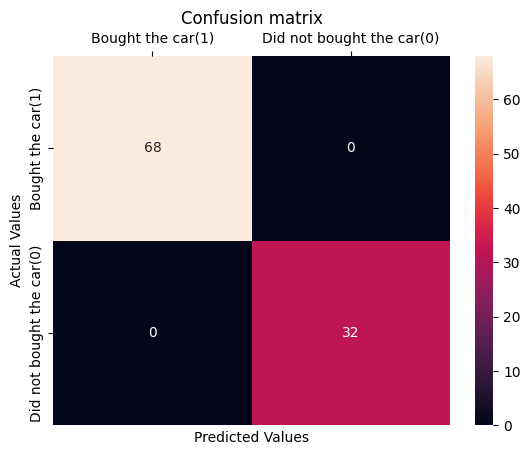

In [11]:
import seaborn as sns

sns.heatmap(cm, annot=True, xticklabels=["Bought the car(1)", "Did not bought the car(0)"], yticklabels=["Bought the car(1)", "Did not bought the car(0)"])
plt.tick_params(axis='x', labeltop=True, labelbottom=False, top=True, bottom=False)

plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")


plt.title("Confusion matrix")

##Accuracy Score

In [12]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_pred, y_test))

1.0
